# Loan Default Classification

In [9]:
# import libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

**Data Preprocessing**

In [10]:
# load data
df = pd.read_csv('/content/Loan_Default.csv')

In [11]:
# view data
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [12]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [13]:
# identify numerical and categorical columns
num_cols = [
    'loan_amount',
    'rate_of_interest',
    'Interest_rate_spread',
    'Upfront_charges',
    'term',
    'property_value',
    'income',
    'Credit_Score',
    'LTV',
    'dtir1'
]

cat_cols = [
    'loan_limit',
    'Gender',
    'approv_in_adv',
    'loan_type',
    'loan_purpose',
    'Credit_Worthiness',
    'open_credit',
    'business_or_commercial',
    'Neg_ammortization',
    'interest_only',
    'lump_sum_payment',
    'construction_type',
    'occupancy_type',
    'Secured_by',
    'total_units',
    'credit_type',
    'co-applicant_credit_type',
    'age',
    'submission_of_application',
    'Region',
    'Security_Type'
]

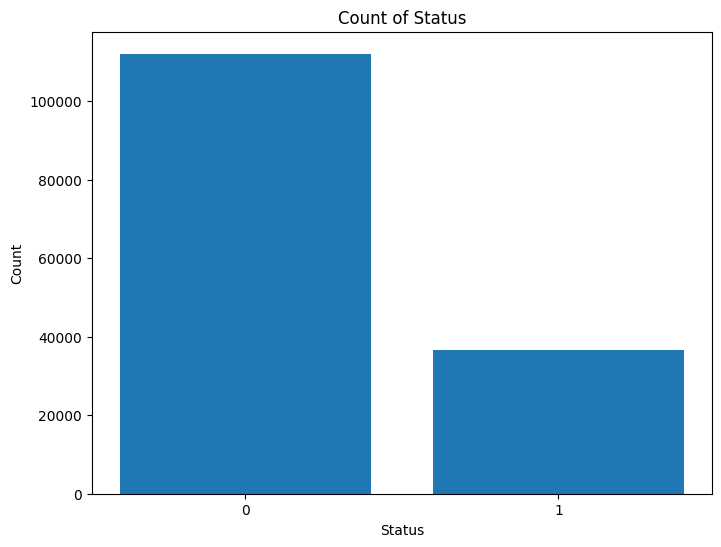

In [14]:
# plot the count of Status=0 and Status=1
status_counts = df['Status'].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(status_counts.index, status_counts)
plt.title('Count of Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['0', '1'])
plt.show()

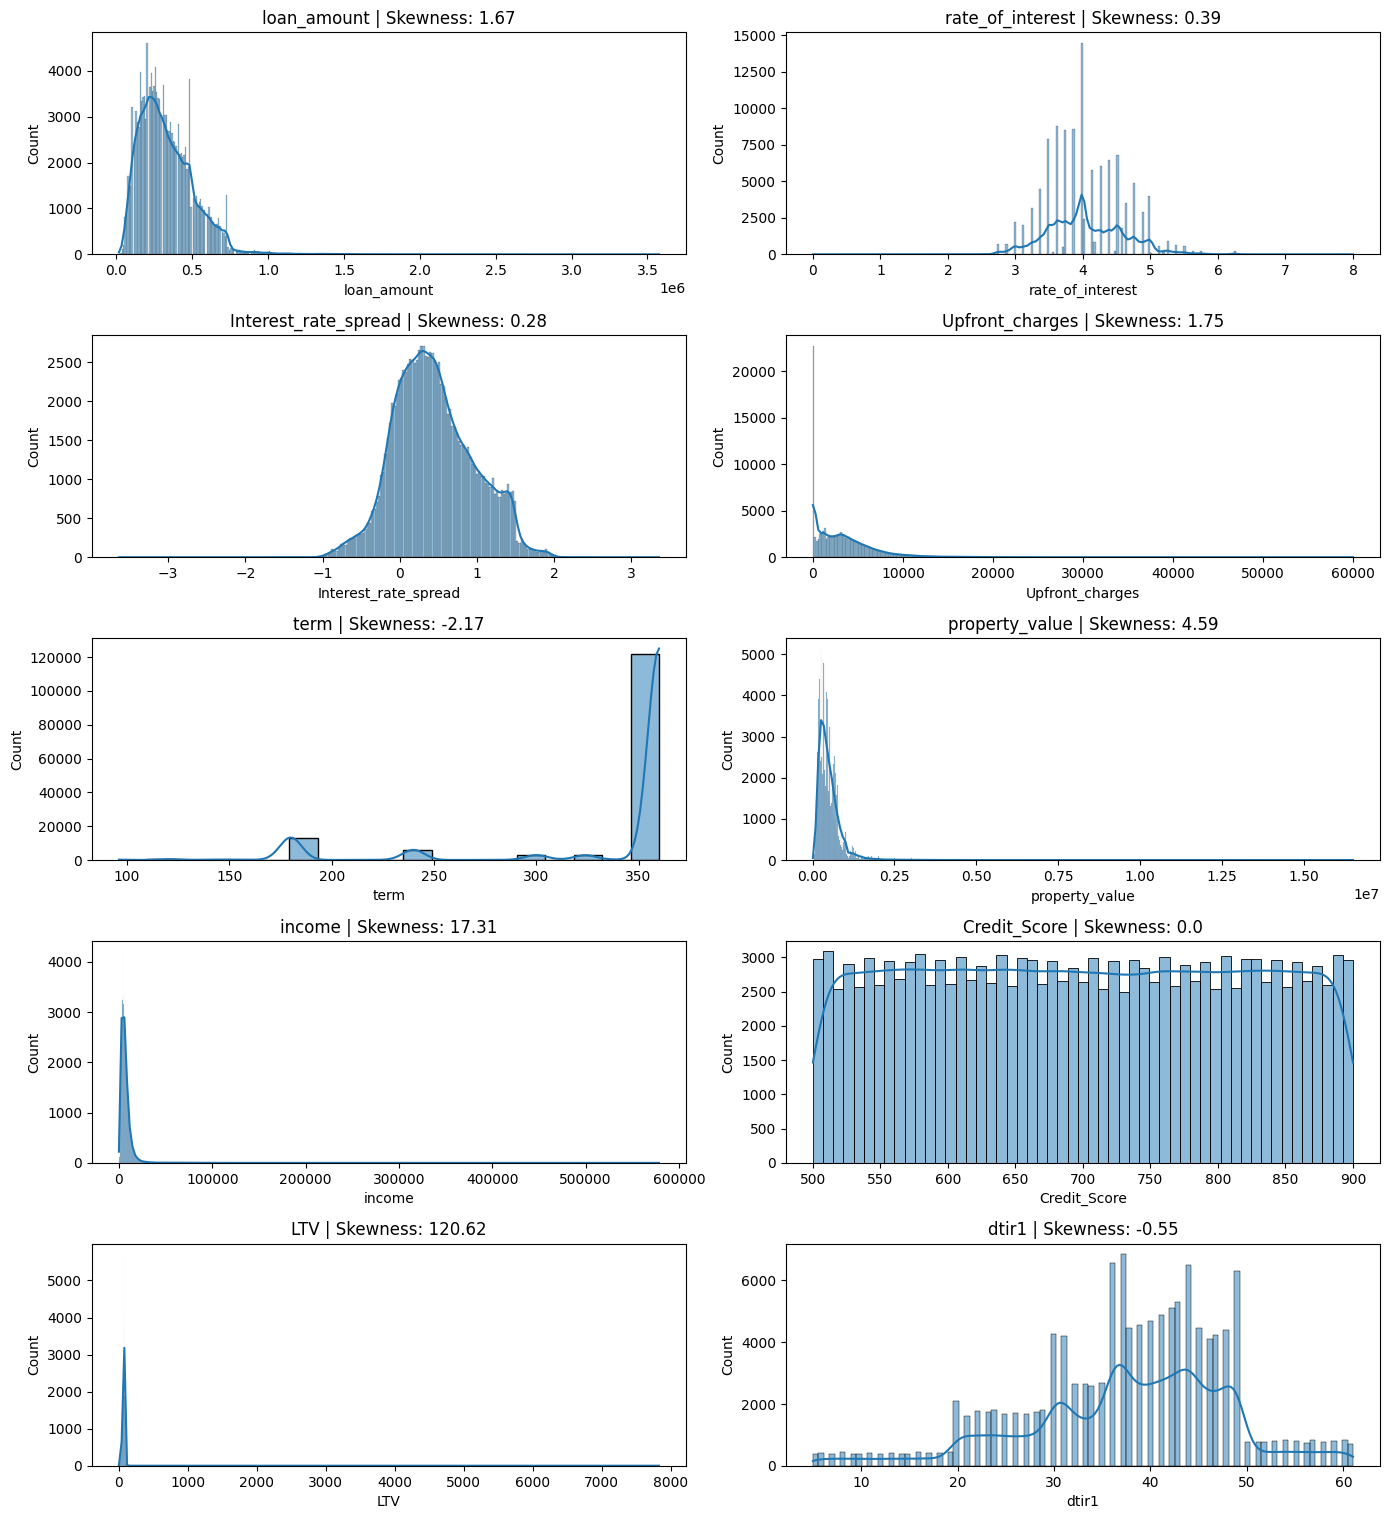

In [15]:
# generate a kernel densitiy plot of the count of each numerical feature
# with skewness to visualize variance in the dataset
plt.figure(figsize=(14, len(num_cols) * 3))
for idx, feature in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

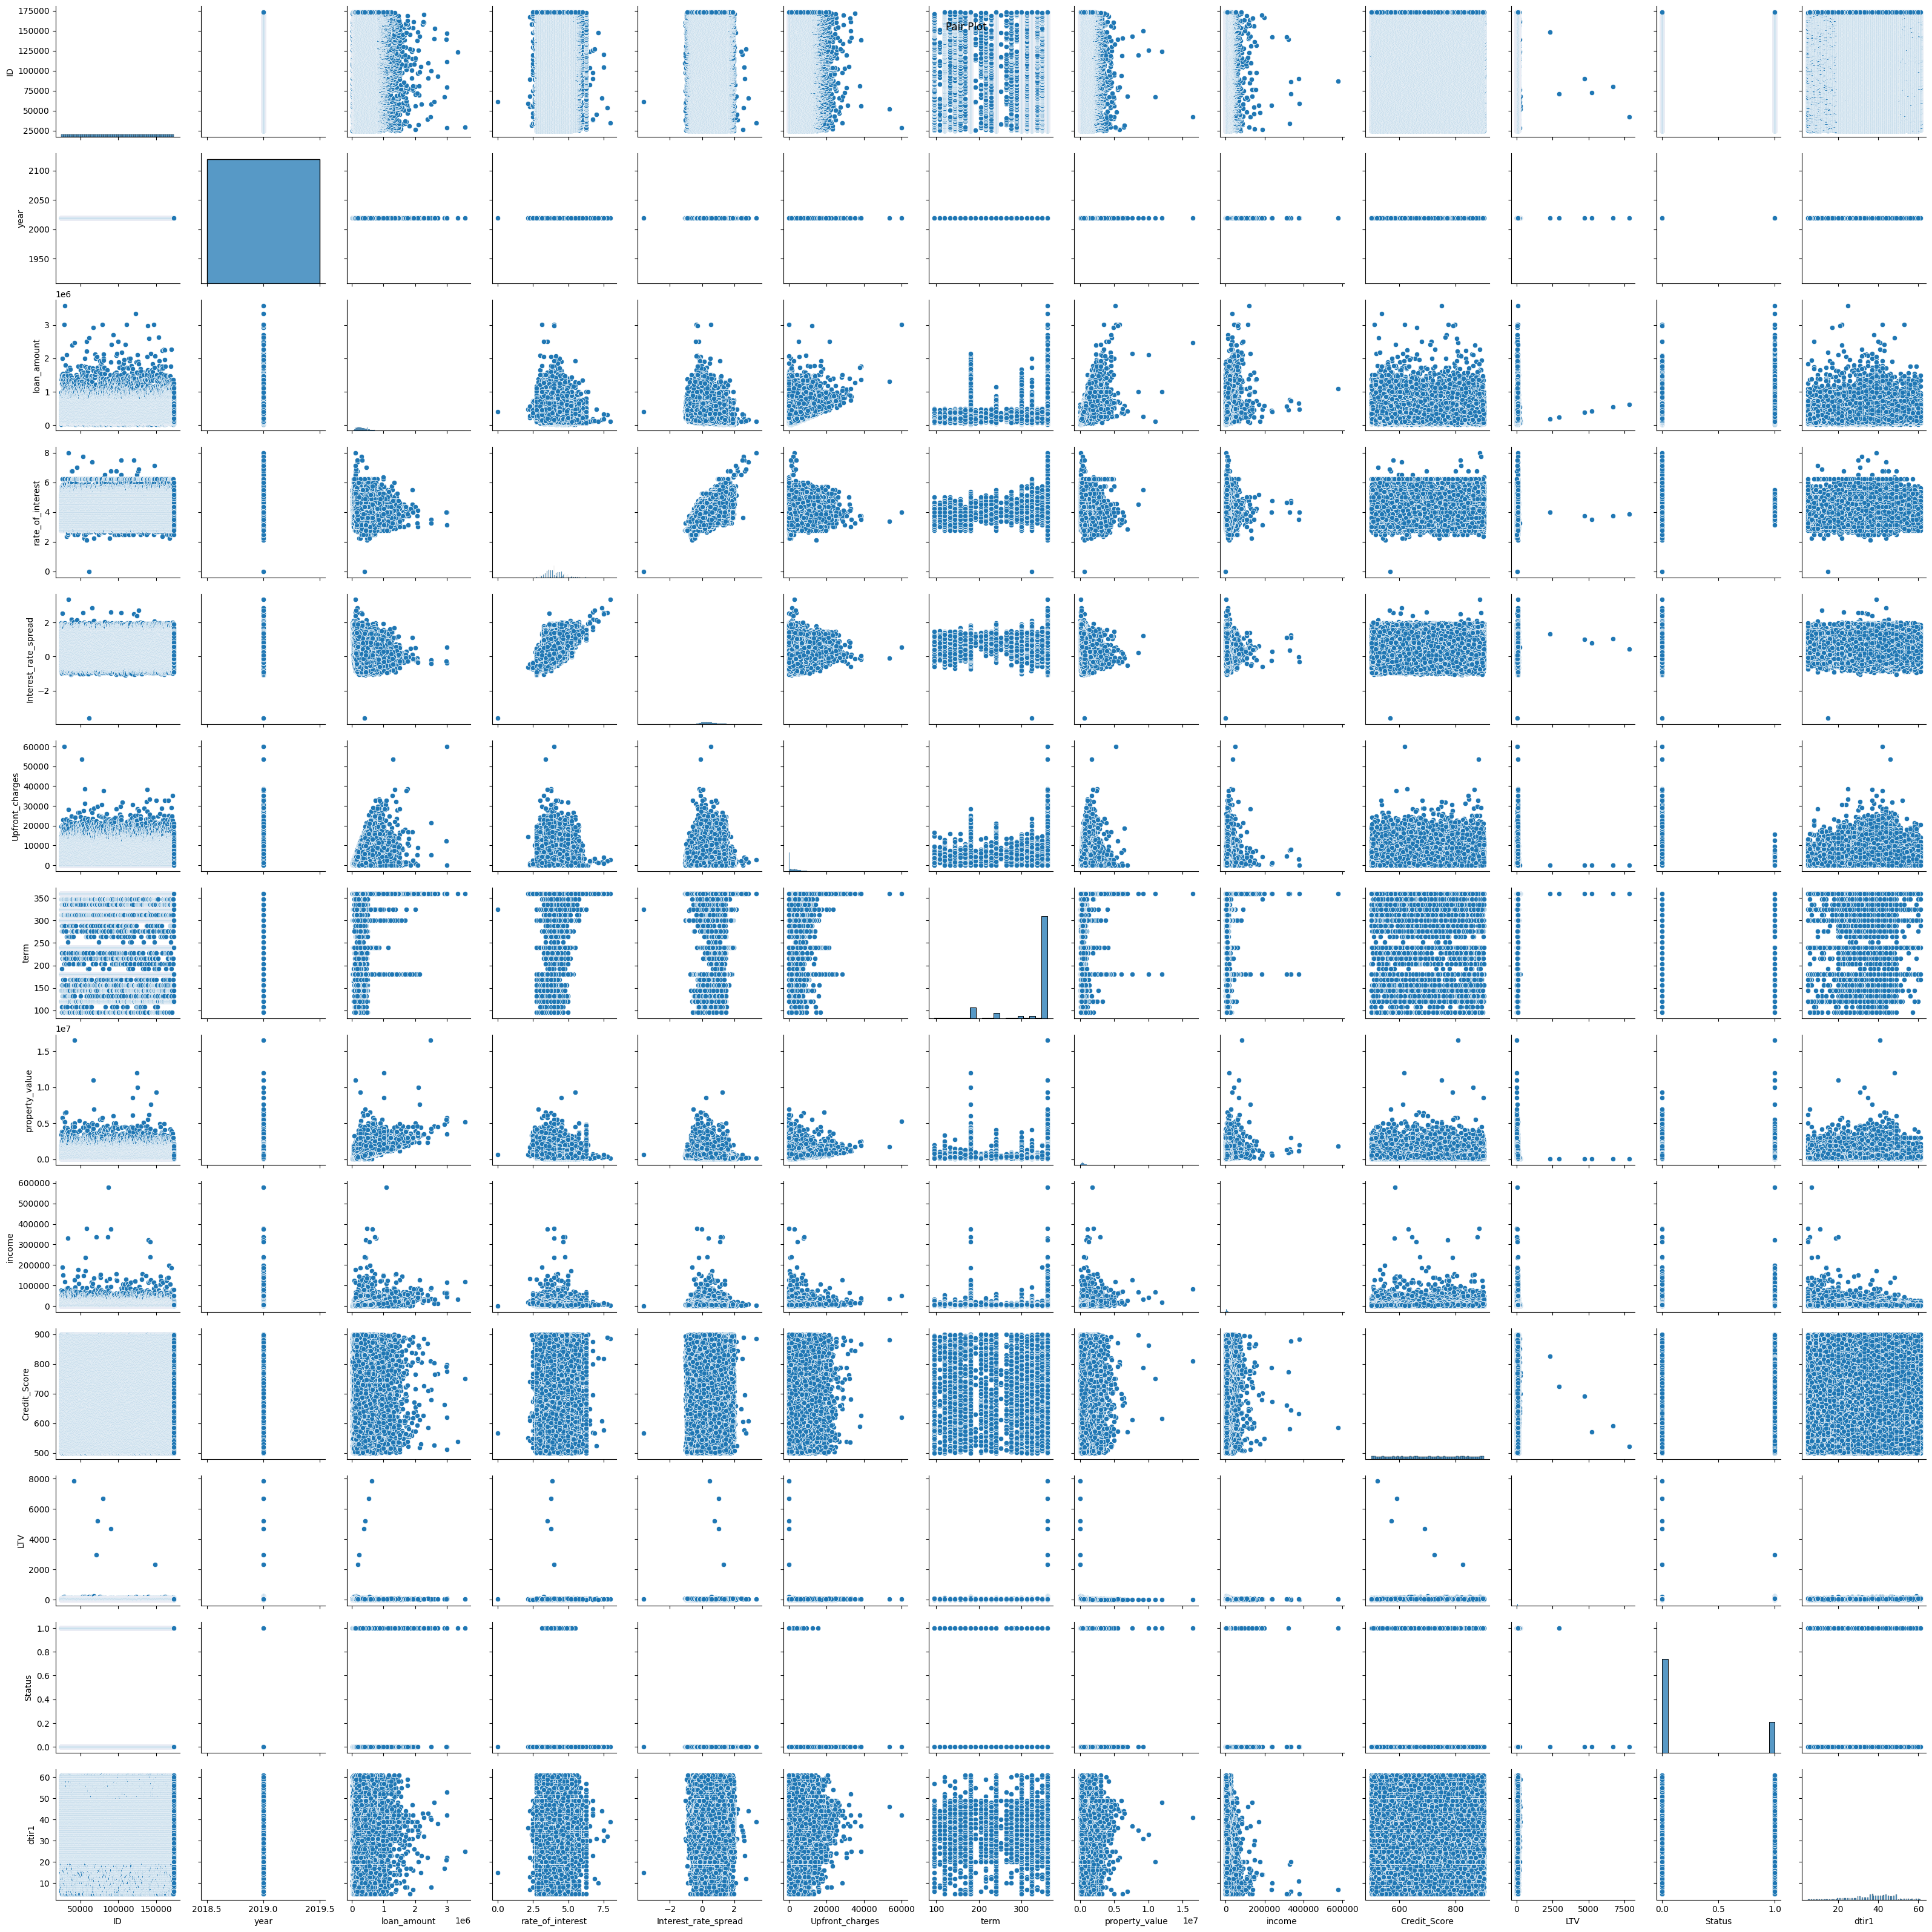

In [16]:
# generate a pair plot to visualize the relationship between pairs of variables
plt.figure(figsize=(10, 6))
sns.pairplot(df)
plt.suptitle('Pair Plot')
plt.show()

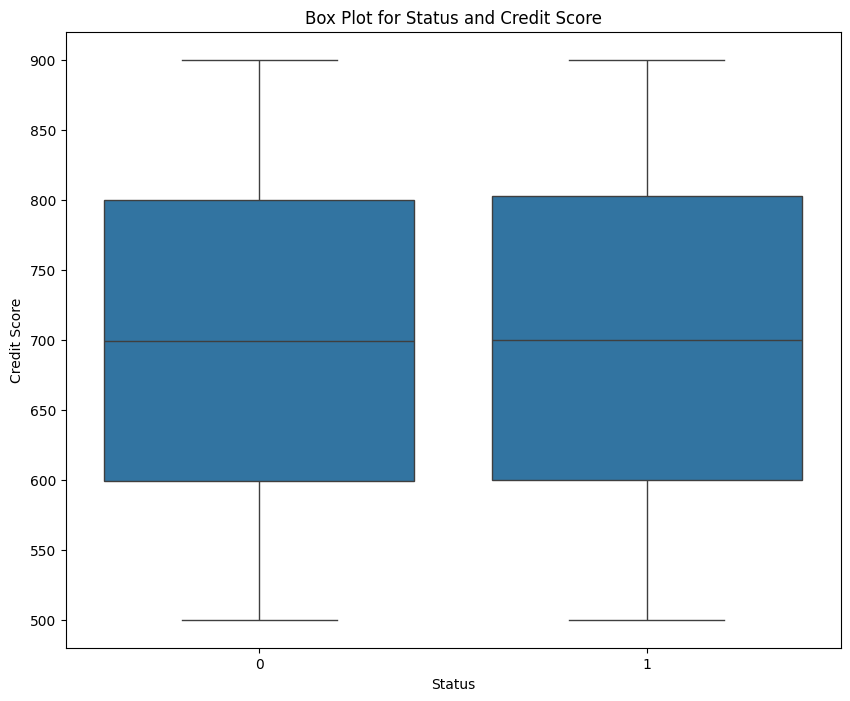

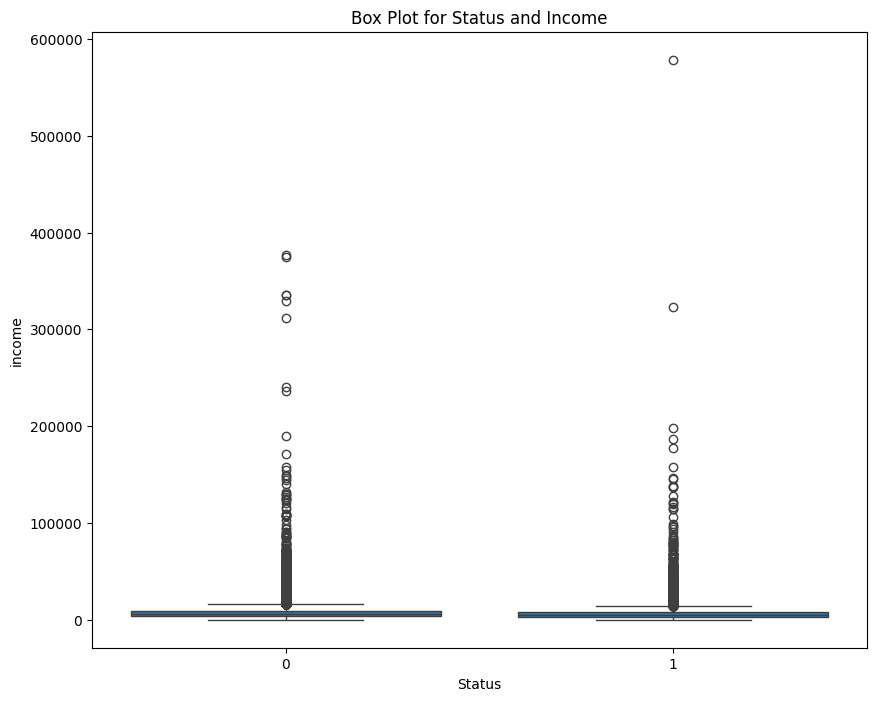

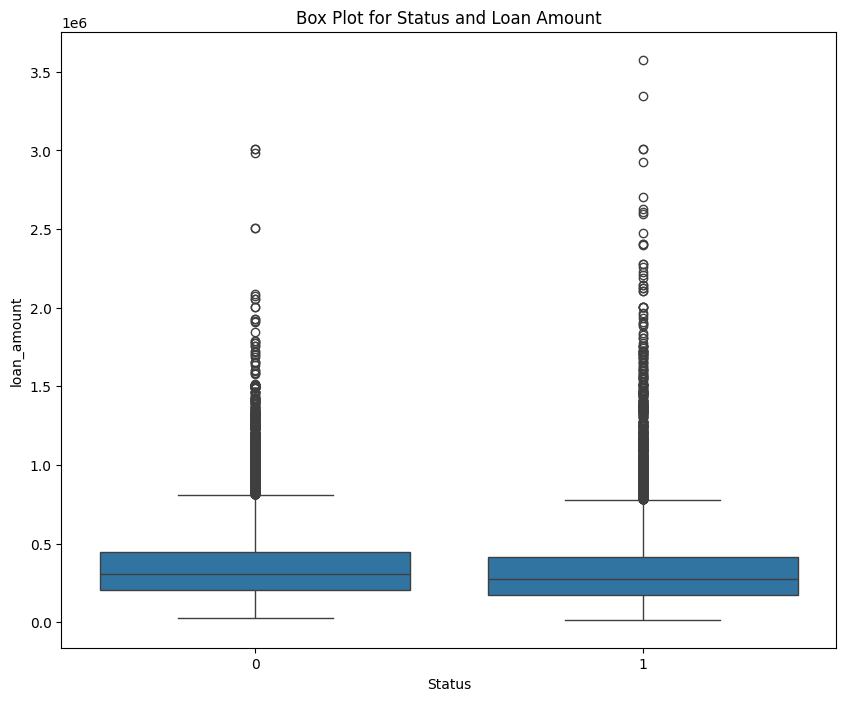

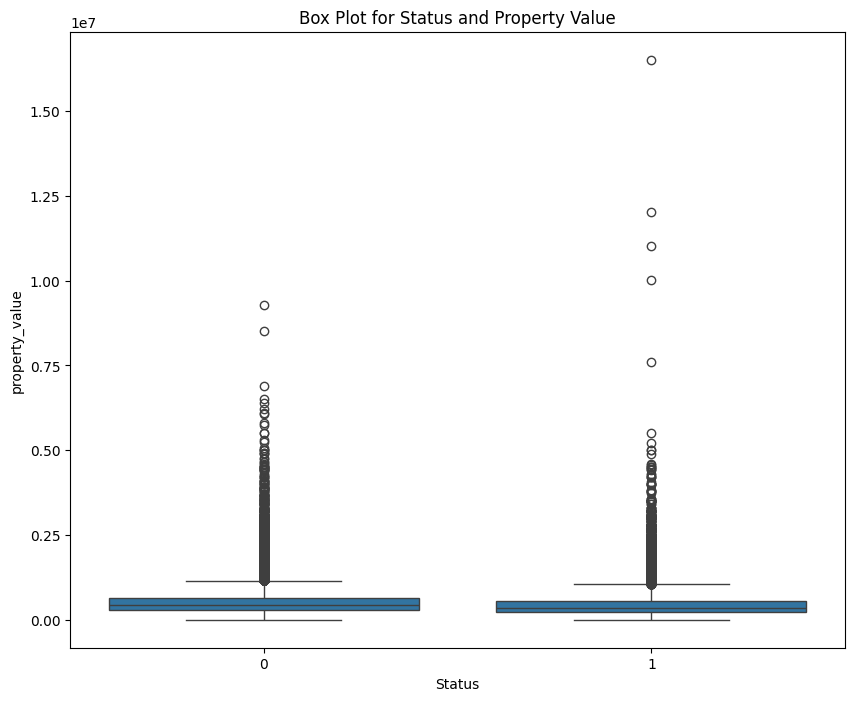

In [17]:
# generate box plots to visualize relationships and check for outliers
plt.figure(figsize=(10, 8))
sns.boxplot(x="Status", y="Credit_Score", data=df)
plt.title('Box Plot for Status and Credit Score')
plt.xlabel('Status')
plt.ylabel('Credit Score')
plt.show()

plt.figure(figsize=(10, 8))
sns.boxplot(x="Status", y="income", data=df)
plt.title('Box Plot for Status and Income')
plt.xlabel('Status')
plt.ylabel('income')
plt.show()

plt.figure(figsize=(10, 8))
sns.boxplot(x="Status", y="loan_amount", data=df)
plt.title('Box Plot for Status and Loan Amount')
plt.xlabel('Status')
plt.ylabel('loan_amount')
plt.show()

plt.figure(figsize=(10, 8))
sns.boxplot(x="Status", y="property_value", data=df)
plt.title('Box Plot for Status and Property Value')
plt.xlabel('Status')
plt.ylabel('property_value')
plt.show()

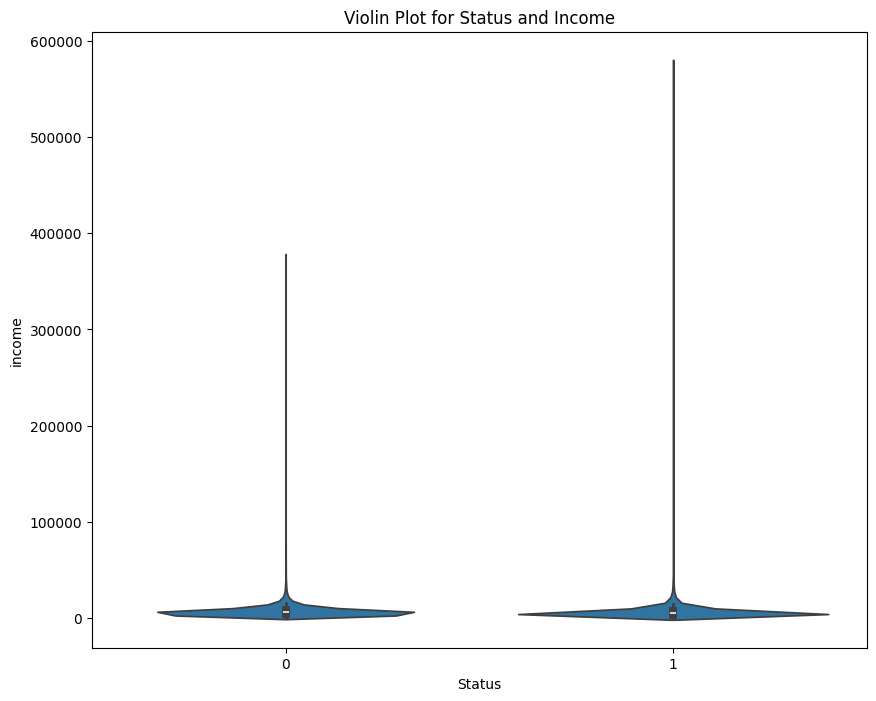

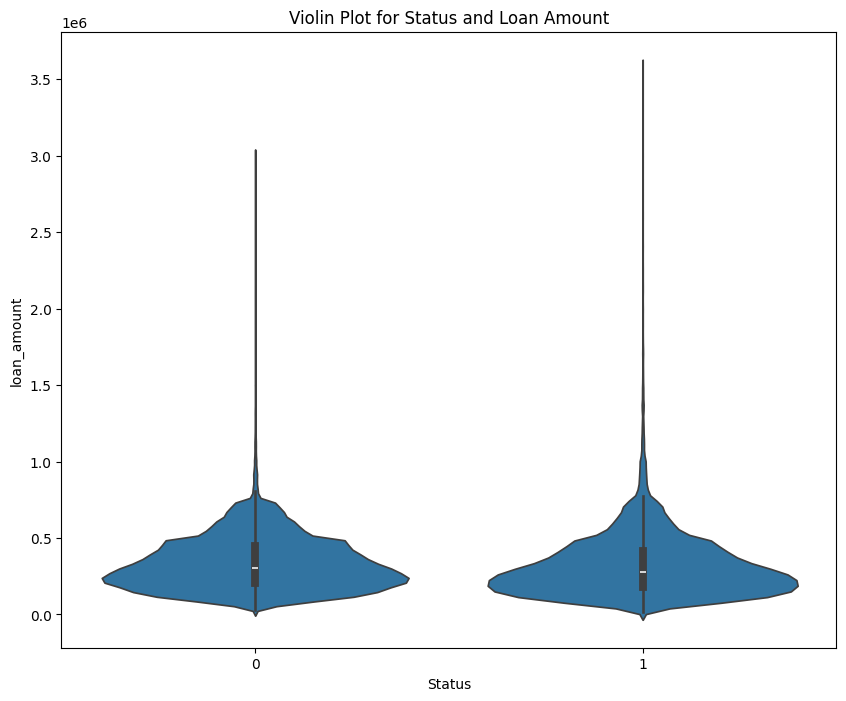

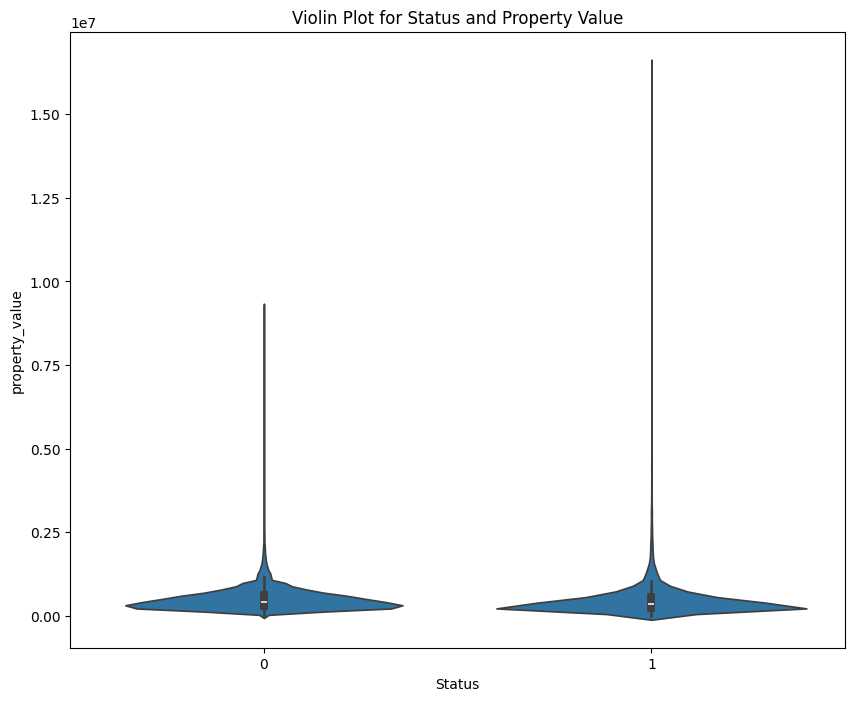

In [18]:
# generate violin plots to visualize relationships
plt.figure(figsize=(10, 8))
sns.violinplot(x="Status", y="income", data=df)
plt.title('Violin Plot for Status and Income')
plt.xlabel('Status')
plt.ylabel('income')
plt.show()

plt.figure(figsize=(10, 8))
sns.violinplot(x="Status", y="loan_amount", data=df)
plt.title('Violin Plot for Status and Loan Amount')
plt.xlabel('Status')
plt.ylabel('loan_amount')
plt.show()

plt.figure(figsize=(10, 8))
sns.violinplot(x="Status", y="property_value", data=df)
plt.title('Violin Plot for Status and Property Value')
plt.xlabel('Status')
plt.ylabel('property_value')
plt.show()

In [19]:
# check for duplicates and missing values
print(f"there are duplicates in the dataframe: {df.duplicated().any()}")
print(f"there are missing values in the dataframe: {df.isnull().values.any()}")

there are duplicates in the dataframe: False
there are missing values in the dataframe: True


In [20]:
# check missing values per column and column data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [21]:
# replace missing values in numerical columns with median column value
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# replace missing values in categorical columns with mode column value
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# check missing values
print(f"number of missing values: {df.isnull().sum().sum()}")

/tmp/ipykernel_1072/2871243568.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1072/2871243568.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

number of missing values: 0


In [22]:
# encode categorical features and scale numerical features
label_encoder = LabelEncoder()
for col in cat_cols:
  df[col] = label_encoder.fit_transform(df[col])

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# drop unnecessary columns
df.drop(columns=['ID', 'year', 'LTV', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges'], inplace=True)

In [23]:
# view modified dataset
df.head()

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,term,...,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Security_Type,Status,dtir1
0,0,3,0,0,0,0,0,1,-1.166980,0.425609,...,-0.816446,3,0.502357,0,0,1,3,1,1,0.730747
1,0,2,0,1,0,0,0,0,-0.677607,0.425609,...,-0.302164,2,-1.275413,1,3,1,0,1,1,0.109847
2,0,2,1,0,0,0,0,1,0.409890,0.425609,...,0.412116,3,1.158234,0,1,1,3,1,0,0.834231
3,0,2,0,0,3,0,0,1,0.681764,0.425609,...,0.793066,3,-0.973365,0,2,0,0,1,0,0.420297
4,0,1,1,0,0,0,0,1,1.986759,0.425609,...,0.564496,1,-0.843916,1,0,0,0,1,0,0.109847


**Feature and Label Definition**

In [24]:
# create target variable
y = df['Status']

# drop target from features
X = df.drop('Status', axis=1)

**Train-Test Split**

In [25]:
# split data set into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Model Training**

In [26]:
# logistic regression
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [27]:
# support vector machine
# model_svm = SVC(kernel='linear', C=1E10)
# model_svm.fit(X_train, y_train)

In [28]:
# random forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Evaluation**

In [29]:
# model testing
y_pred_lr = model_lr.predict(X_test)
#y_pred_svm = model.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

In [30]:
# accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
#accuracy_svm = accuracy_score(y_test, y_pred_svm)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy:", accuracy_lr)
#print("Support Vector Machine Accuracy:", accuracy_svm)
print("Random Forest Accuracy:", accuracy_rf)

Logistic Regression Accuracy: 0.7773592520347078
Random Forest Accuracy: 0.8835003699468622


In [31]:
# classification report
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))
#print("Support Vector Machine Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.97      0.87     22494
           1       0.64      0.19      0.30      7240

    accuracy                           0.78     29734
   macro avg       0.72      0.58      0.58     29734
weighted avg       0.75      0.78      0.73     29734

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93     22494
           1       0.92      0.57      0.70      7240

    accuracy                           0.88     29734
   macro avg       0.90      0.78      0.82     29734
weighted avg       0.89      0.88      0.87     29734



Logistic Regression Confusion Matrix:
 [[21725   769]
 [ 5851  1389]]


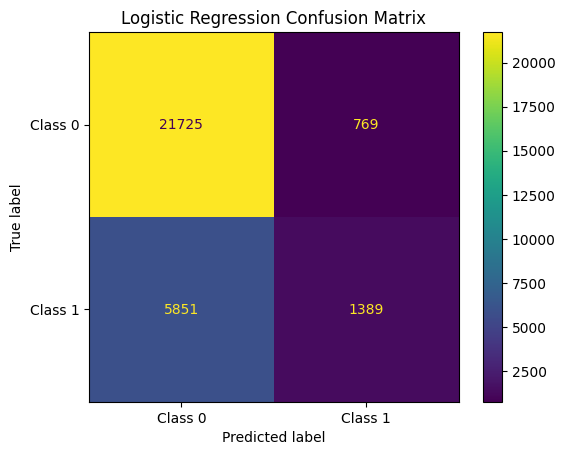

Random Forest Confusion Matrix:
 [[22152   342]
 [ 3122  4118]]


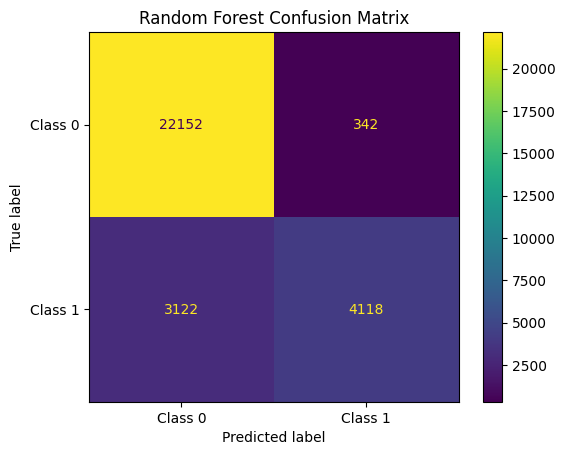

In [37]:
# confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Logistic Regression Confusion Matrix:\n", cm_lr)

cm_display_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Class 0", "Class 1"])
cm_display_lr.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#cm_svm = confusion_matrix(y_test, y_pred_svm)
#print("Support Vector Machine Confusion Matrix:\n", cm_svm)

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:\n", cm_rf)

cm_display_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Class 0", "Class 1"])
cm_display_rf.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

**Model Comparison**

In [38]:
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

precision_lr = report_lr['1']['precision']
recall_lr = report_lr['1']['recall']
f1_lr = report_lr['1']['f1-score']

precision_rf = report_rf['1']['precision']
recall_rf = report_rf['1']['recall']
f1_rf = report_rf['1']['f1-score']

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Precision (Class 1): {precision_lr:.4f}")
print(f"Logistic Regression Recall (Class 1): {recall_lr:.4f}")
print(f"Logistic Regression F1-score (Class 1): {f1_lr:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision (Class 1): {precision_rf:.4f}")
print(f"Random Forest Recall (Class 1): {recall_rf:.4f}")
print(f"Random Forest F1-score (Class 1): {f1_rf:.4f}")

Logistic Regression Accuracy: 0.7774
Logistic Regression Precision (Class 1): 0.6437
Logistic Regression Recall (Class 1): 0.1919
Logistic Regression F1-score (Class 1): 0.2956
Random Forest Accuracy: 0.8835
Random Forest Precision (Class 1): 0.9233
Random Forest Recall (Class 1): 0.5688
Random Forest F1-score (Class 1): 0.7039


In [39]:
data = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_rf],
    'Precision': [precision_lr, precision_rf],
    'Recall': [recall_lr, recall_rf],
    'F1-score': [f1_lr, f1_rf]
}
metrics_df = pd.DataFrame(data)
print(metrics_df)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.777359   0.643652  0.191851  0.295595
1        Random Forest  0.883500   0.923318  0.568785  0.703932


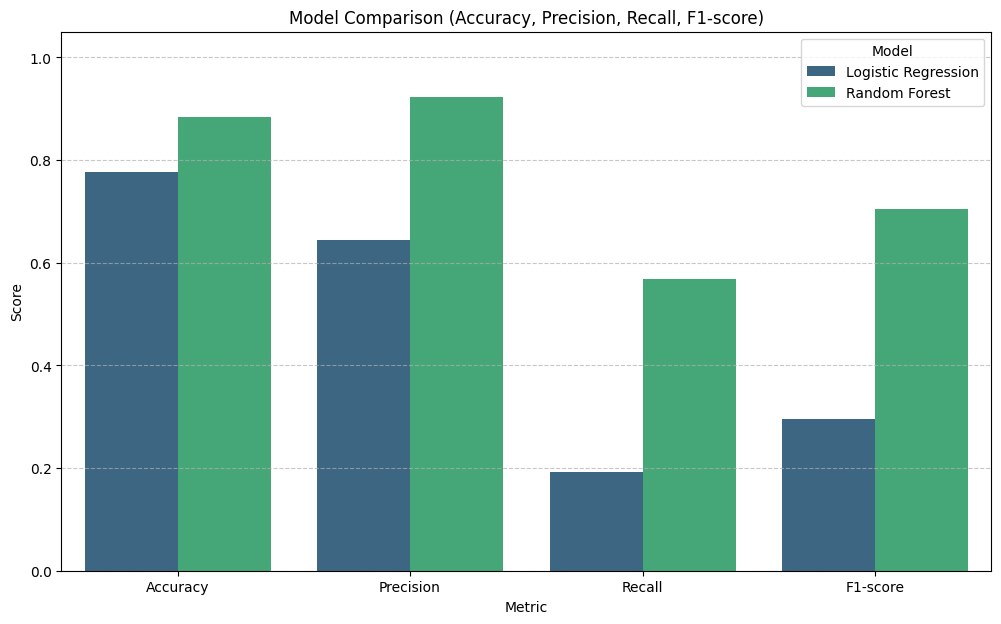

In [40]:
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Model Comparison (Accuracy, Precision, Recall, F1-score)')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


**Conclusion**

The Random Forest model scored higher in accuracy, precision, recall and F1-score than the Logistic Regression model.
* Most correctly classified instances (highest accuracy): Random Forest
* Least false positives (highest precision): Random Forest
* Least false negatives (highest recall): Random Forest
* Best balance between precision and recall (highest F1-score): Random Forest

The Random Forest model performed better than Logistic Regression for predicting loan defaults. Its high performance across all metrics indicates its ability to accurately classify both non-default and default cases with very few errors. The Logistic Regression model scored lower which means it is not as reliable for predicting actual loan defaults.